In [3]:
# Build on the MLP from scratchpad_mlp2 to arrive at an architecture similar to Google DeepMind's WaveNet Convolutional Neural Network

import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [5]:
random.seed(42)
random.shuffle(words)

In [6]:
# build the dataset

block_size = 3 # context length

def build_dataset(words):
    X, Y = [], []
    for w in words[:10000]:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [7]:
for x,y in zip(Xtr[:10], Ytr[:10]):
    print(''.join(itos[i.item()] for i in x), '---->', itos[y.item()])

... ----> y
..y ----> u
.yu ----> h
yuh ----> e
uhe ----> n
hen ----> g
eng ----> .
... ----> d
..d ----> i
.di ----> o


In [8]:
# Layer Module Definition (PyTorch API)

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # kaiming init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:
    
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (learnable via backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (not learnable, but part of the state)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x):
        # calculate forward pass
        if self.training:
            self.mean = x.mean(0, keepdim=True)
            self.var = x.var(0, keepdim=True)
        else:
            self.mean = self.running_mean
            self.var = self.running_var
        xhat = (x - self.mean) / torch.sqrt(self.var + self.eps)
        self.out = self.gamma * xhat + self.beta
        # update running stats
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * self.var
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []


In [9]:
torch.manual_seed(42)

In [11]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP

C = torch.randn((vocab_size, n_embd)) # character embedding table
layers = [Linear(n_embd * block_size, n_hidden, bias=False), 
          BatchNorm1d(n_hidden), 
          Tanh(),
          Linear(n_hidden, vocab_size)]

# parameters init
with torch.no_grad():
    layers[-1].weight *= 0.1 # make last layer less confident
    
parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

In [12]:
# Stochastic Gradient Descent
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    emb = C[Xb] # (32, 3, 10)
    x = emb.view(emb.shape[0], -1) # (32, 30)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update gradients
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} --- loss: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000 --- loss: 3.3019
  10000/ 200000 --- loss: 2.1777
  20000/ 200000 --- loss: 2.9006
  30000/ 200000 --- loss: 2.3951
  40000/ 200000 --- loss: 2.0932
  50000/ 200000 --- loss: 1.8520
  60000/ 200000 --- loss: 2.3361
  70000/ 200000 --- loss: 2.2821
  80000/ 200000 --- loss: 2.2290
  90000/ 200000 --- loss: 2.4626
 100000/ 200000 --- loss: 2.3044
 110000/ 200000 --- loss: 2.4558
 120000/ 200000 --- loss: 2.6354
 130000/ 200000 --- loss: 2.2563
 140000/ 200000 --- loss: 2.6065
 150000/ 200000 --- loss: 1.9527
 160000/ 200000 --- loss: 2.1495
 170000/ 200000 --- loss: 2.0269
 180000/ 200000 --- loss: 2.0434
 190000/ 200000 --- loss: 2.4509


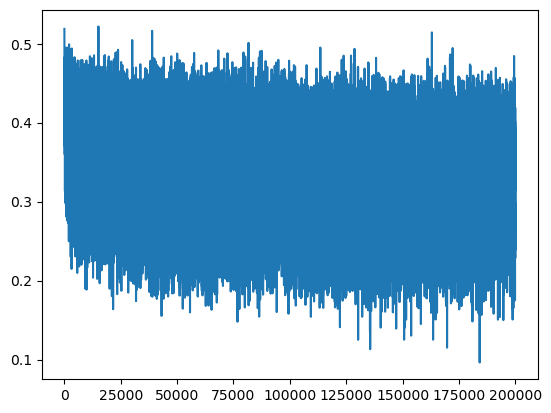

In [13]:
plt.plot(lossi)

In [14]:
# put layers into eval mode
for layer in layers:
    layer.training = False

In [16]:
# evaluate the loss on dev set
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 
            'dev': (Xdev, Ydev), 
            'test': (Xte, Yte),
            }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('dev')

train loss: 2.0729
dev loss: 2.1666


In [20]:
# sample from the model

for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
        # forward pass
        emb = C[torch.tensor([context])] # (1, block_size, n_embd)
        x = emb.view(emb.shape[0], -1) # (1, block_size * n_embd)
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

jamill.
machiree.
yan.
zairosyre.
delynn.
tourtt.
astina.
saberkana.
kendalynycinnashi.
jacallamie.
shref.
aver.
breydilyanven.
jona.
kaney.
jourah.
bresytie.
maleeyataina.
caustyn.
kahrhoen.
